# Correlation Analysis
Analysis of correlations in both datasets using Pearson and Spearman methods.

In [26]:
# Imports & Helper Functions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')
print(" Correlation Analysis Framework Ready")

 Correlation Analysis Framework Ready


In [27]:
# Pearson Correlation Function

def pearson_correlation_test(df, col1, col2):
    """
    Calculate Pearson correlation coefficient and p-value
    Parameters:
    - df: DataFrame
    - col1, col2: Column names
    Returns:
    - Dictionary with correlation and p-value
    """
    corr, pvalue = pearsonr(df[col1], df[col2])
    return {
        'variable_1': col1,
        'variable_2': col2,
        'correlation': round(corr, 4),
        'p_value': round(pvalue, 6),
        'significant': 'Yes' if pvalue < 0.05 else 'No'
    }
print(" Pearson correlation function defined")

 Pearson correlation function defined


In [28]:

# Spearman Correlation Function

def spearman_correlation_test(df, col1, col2):
    """
    Calculate Spearman rank correlation coefficient and p-value
    Parameters:
    - df: DataFrame
    - col1, col2: Column names
    Returns:
    - Dictionary with correlation and p-value
    """
    corr, pvalue = spearmanr(df[col1], df[col2])
    return {
        'variable_1': col1,
        'variable_2': col2,
        'correlation': round(corr, 4),
        'p_value': round(pvalue, 6),
        'significant': 'Yes' if pvalue < 0.05 else 'No'
    }
print(" Spearman correlation function defined")

 Spearman correlation function defined


In [29]:

#  Batch Correlation Analysis
def analyze_all_correlations(df, method='pearson'):
    """
    Calculate correlations for all numeric column pairs
    Parameters:
    - df: DataFrame
    - method: 'pearson' or 'spearman'
    Returns:
    - Pandas DataFrame with results
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    results = []
    for i, col1 in enumerate(numeric_cols):
        for col2 in numeric_cols[i+1:]:
            if method == 'pearson':
                result = pearson_correlation_test(df, col1, col2)
            else:
                result = spearman_correlation_test(df, col1, col2)
            results.append(result)
    return pd.DataFrame(results)
print(" Batch correlation analysis function defined")

 Batch correlation analysis function defined


## Student Data Correlation Analysis

In [30]:
# Load & Analyze Student Data
# Load student data
df_student = pd.read_csv('../data/ai_assistant_usage_student_life.csv')
print("\n" + "="*60)
print("STUDENT DATA - PEARSON CORRELATION ANALYSIS")
print("="*60)
student_pearson = analyze_all_correlations(df_student, method='pearson')
print(student_pearson.to_string(index=False))


STUDENT DATA - PEARSON CORRELATION ANALYSIS
        variable_1         variable_2  correlation  p_value significant
  SessionLengthMin       TotalPrompts       0.9023 0.000000         Yes
  SessionLengthMin AI_AssistanceLevel      -0.0068 0.493526          No
  SessionLengthMin SatisfactionRating      -0.0111 0.265502          No
      TotalPrompts AI_AssistanceLevel      -0.0064 0.525173          No
      TotalPrompts SatisfactionRating      -0.0096 0.339081          No
AI_AssistanceLevel SatisfactionRating       0.7755 0.000000         Yes


In [31]:
# Spearman Correlation - Student
print("\n" + "="*60)
print("STUDENT DATA - SPEARMAN CORRELATION ANALYSIS")
print("="*60)
student_spearman = analyze_all_correlations(df_student, method='spearman')
print(student_spearman.to_string(index=False))


STUDENT DATA - SPEARMAN CORRELATION ANALYSIS
        variable_1         variable_2  correlation  p_value significant
  SessionLengthMin       TotalPrompts       0.9339 0.000000         Yes
  SessionLengthMin AI_AssistanceLevel      -0.0071 0.479748          No
  SessionLengthMin SatisfactionRating      -0.0083 0.405932          No
      TotalPrompts AI_AssistanceLevel      -0.0084 0.400332          No
      TotalPrompts SatisfactionRating      -0.0098 0.328661          No
AI_AssistanceLevel SatisfactionRating       0.7720 0.000000         Yes


## Workforce Data Correlation Analysis

In [32]:
# Load & Analyze Workforce Data
# Load workforce data
df_workforce = pd.read_csv('../data/global_ai_workforce_automation_2015_2025.csv')
print("\n" + "="*60)
print("WORKFORCE DATA - PEARSON CORRELATION ANALYSIS")
print("="*60)
workforce_pearson = analyze_all_correlations(df_workforce, method='pearson')
print(workforce_pearson.to_string(index=False))


WORKFORCE DATA - PEARSON CORRELATION ANALYSIS
                      variable_1                       variable_2  correlation  p_value significant
                            Year         AI_Investment_BillionUSD       0.4618 0.000000         Yes
                            Year          Automation_Rate_Percent       0.3574 0.000000         Yes
                            Year          Employment_Rate_Percent      -0.1909 0.004479         Yes
                            Year               Average_Salary_USD       0.3049 0.000004         Yes
                            Year               Productivity_Index       0.3790 0.000000         Yes
                            Year Reskilling_Investment_MillionUSD       0.4884 0.000000         Yes
                            Year                  AI_Policy_Index      -0.1278 0.058401          No
                            Year         Job_Displacement_Million       0.1515 0.024619         Yes
                            Year             Job_Crea

In [33]:
# Spearman Correlation - Workforce

print("\n" + "="*60)
print("WORKFORCE DATA - SPEARMAN CORRELATION ANALYSIS")
print("="*60)
workforce_spearman = analyze_all_correlations(df_workforce, method='spearman')
print(workforce_spearman.to_string(index=False))


WORKFORCE DATA - SPEARMAN CORRELATION ANALYSIS
                      variable_1                       variable_2  correlation  p_value significant
                            Year         AI_Investment_BillionUSD       0.4519 0.000000         Yes
                            Year          Automation_Rate_Percent       0.3410 0.000000         Yes
                            Year          Employment_Rate_Percent      -0.1868 0.005450         Yes
                            Year               Average_Salary_USD       0.2971 0.000007         Yes
                            Year               Productivity_Index       0.3866 0.000000         Yes
                            Year Reskilling_Investment_MillionUSD       0.4629 0.000000         Yes
                            Year                  AI_Policy_Index      -0.1323 0.050001          No
                            Year         Job_Displacement_Million       0.1384 0.040215         Yes
                            Year             Job_Cre

In [34]:
#  Significant Correlations Summary
print("\n" + "="*60)
print("SIGNIFICANT CORRELATIONS (p < 0.05)")
print("="*60)
print("\n Student Data - Significant Correlations:")
sig_student = student_pearson[student_pearson['p_value'] < 0.05]
if len(sig_student) > 0:
    print(sig_student.to_string(index=False))
else:
    print("  No significant Pearson correlations found")
print("\n Workforce Data - Significant Correlations:")
sig_workforce = workforce_pearson[workforce_pearson['p_value'] < 0.05]
if len(sig_workforce) > 0:
    print(sig_workforce.to_string(index=False))
else:
    print("  No significant Pearson correlations found")


SIGNIFICANT CORRELATIONS (p < 0.05)

 Student Data - Significant Correlations:
        variable_1         variable_2  correlation  p_value significant
  SessionLengthMin       TotalPrompts       0.9023      0.0         Yes
AI_AssistanceLevel SatisfactionRating       0.7755      0.0         Yes

 Workforce Data - Significant Correlations:
                      variable_1                       variable_2  correlation  p_value significant
                            Year         AI_Investment_BillionUSD       0.4618 0.000000         Yes
                            Year          Automation_Rate_Percent       0.3574 0.000000         Yes
                            Year          Employment_Rate_Percent      -0.1909 0.004479         Yes
                            Year               Average_Salary_USD       0.3049 0.000004         Yes
                            Year               Productivity_Index       0.3790 0.000000         Yes
                            Year Reskilling_Investment_Mill

In [35]:
from scipy.stats import pointbiserialr

# Point-Biserial Correlation Function
def pointbiserial_correlation_test(df, col_binary, col_continuous):
    """
    Calculate Point-Biserial correlation coefficient and p-value.
    
    Parameters:
    - df: DataFrame
    - col_binary: Column name (binary: 0/1)
    - col_continuous: Column name (continuous)
    
    Returns:
    - Dictionary with correlation and p-value
    """
    corr, pvalue = pointbiserialr(df[col_binary], df[col_continuous])
    
    return {
        'variable1': col_binary,
        'variable2': col_continuous,
        'correlation': round(corr, 4),
        'pvalue': round(pvalue, 6),
        'significant': 'Yes' if pvalue < 0.05 else 'No'
    }

print("Point-Biserial correlation function defined")


Point-Biserial correlation function defined


In [36]:
# Create binary variable from continuous (e.g., SessionLengthMin > median = 1, else 0)
df_student['LongSession'] = (df_student['SessionLengthMin'] > df_student['SessionLengthMin'].median()).astype(int)

# Test Point-Biserial correlation
pb_result = pointbiserial_correlation_test(df_student, 'LongSession', 'TotalPrompts')
print("\nPOINT-BISERIAL CORRELATION EXAMPLE:")
print(f"Binary Variable (LongSession) vs Continuous Variable (TotalPrompts)")
print(f"Correlation: {pb_result['correlation']}")
print(f"P-value: {pb_result['pvalue']}")
print(f"Significant: {pb_result['significant']}")



POINT-BISERIAL CORRELATION EXAMPLE:
Binary Variable (LongSession) vs Continuous Variable (TotalPrompts)
Correlation: 0.6776
P-value: 0.0
Significant: Yes


In [37]:
from scipy.stats import chi2_contingency
import numpy as np

def phi_coefficient(df, col1_binary, col2_binary):
    """
    Calculate Phi coefficient for two binary variables.
    
    Parameters:
    - df: DataFrame
    - col1_binary: Binary column 1 (0/1)
    - col2_binary: Binary column 2 (0/1)
    
    Returns:
    - Dictionary with phi coefficient and p-value
    """
    # Create contingency table
    contingency_table = pd.crosstab(df[col1_binary], df[col2_binary])
    
    # Chi-square test
    chi2, pvalue, dof, expected = chi2_contingency(contingency_table)
    
    # Calculate Phi coefficient
    n = df.shape
    phi = np.sqrt(chi2 / n) if n > 0 else 0
    
    return {
        'variable1': col1_binary,
        'variable2': col2_binary,
        'phi_coefficient': round(phi, 4),
        'chi_square': round(chi2, 4),
        'pvalue': round(pvalue, 6),
        'significant': 'Yes' if pvalue < 0.05 else 'No'
    }

print("Phi coefficient function defined")


Phi coefficient function defined


In [38]:
# COMPLETE PHI COEFFICIENT ANALYSIS


from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

print("Step 1: Create ALL binary variables from scratch...")
print("-" * 70)

# Create binary variables (do this first, unconditionally)
df_student['HighSatisfaction'] = (df_student['SatisfactionRating'] > df_student['SatisfactionRating'].median()).astype(int)
df_student['HighAssistance'] = (df_student['AI_AssistanceLevel'] > df_student['AI_AssistanceLevel'].median()).astype(int)
df_student['HighPrompts'] = (df_student['TotalPrompts'] > df_student['TotalPrompts'].median()).astype(int)

print("✓ Binary variables created")
print(f"  LongSession: {df_student['LongSession'].sum()} / {len(df_student)}")
print(f"  HighSatisfaction: {df_student['HighSatisfaction'].sum()} / {len(df_student)}")
print(f"  HighAssistance: {df_student['HighAssistance'].sum()} / {len(df_student)}")
print(f"  HighPrompts: {df_student['HighPrompts'].sum()} / {len(df_student)}")

print("\n\nStep 2: Define Phi Coefficient Function...")
print("-" * 70)

def phi_coefficient(df, col1_binary, col2_binary):
    """Calculate Phi coefficient (Binary vs Binary)."""
    valid_idx = ~(df[col1_binary].isnull() | df[col2_binary].isnull())
    contingency_table = pd.crosstab(df.loc[valid_idx, col1_binary], 
                                     df.loc[valid_idx, col2_binary])
    chi2, pvalue, dof, expected = chi2_contingency(contingency_table)
    n = valid_idx.sum()
    phi = np.sqrt(chi2 / n) if n > 0 else 0
    pvalue_str = "< 0.001" if pvalue < 0.001 else f"{pvalue:.6f}"
    
    return {
        'variable1': col1_binary,
        'variable2': col2_binary,
        'phi_coefficient': round(phi, 4),
        'chi_square': round(chi2, 4),
        'pvalue': pvalue,
        'pvalue_formatted': pvalue_str,
        'significant': 'Yes' if pvalue < 0.05 else 'No',
        'n_samples': n
    }

print("✓ Function defined")

print("\n\nStep 3: Run Phi Coefficient Tests...")
print("-" * 70)

phi_results = [
    phi_coefficient(df_student, 'LongSession', 'HighAssistance'),
    phi_coefficient(df_student, 'LongSession', 'HighSatisfaction'),
    phi_coefficient(df_student, 'HighPrompts', 'HighSatisfaction'),
    phi_coefficient(df_student, 'HighPrompts', 'HighAssistance'),
    phi_coefficient(df_student, 'HighAssistance', 'HighSatisfaction'),
]

phi_df = pd.DataFrame(phi_results)

print("\nPHI COEFFICIENT RESULTS:")
print(phi_df[['variable1', 'variable2', 'phi_coefficient', 'pvalue_formatted', 'significant']].to_string(index=False))

print("\n\nStep 4: Detailed Results with Interpretation...")
print("-" * 70)

for idx, row in phi_df.iterrows():
    print(f"\n{idx + 1}. {row['variable1']} ↔ {row['variable2']}")
    print(f"   Phi Coefficient: {row['phi_coefficient']}")
    print(f"   Chi-Square: {row['chi_square']}")
    print(f"   P-value: {row['pvalue_formatted']}")
    print(f"   Significant: {row['significant']}")
    
    phi_abs = abs(row['phi_coefficient'])
    if phi_abs >= 0.50:
        strength = "STRONG"
    elif phi_abs >= 0.30:
        strength = "MODERATE"
    elif phi_abs >= 0.10:
        strength = "WEAK"
    else:
        strength = "NEGLIGIBLE"
    
    print(f"   → Strength: {strength}")

print("\n" + "="*70)
print("ANALYSIS COMPLETE ✓")
print("="*70)


Step 1: Create ALL binary variables from scratch...
----------------------------------------------------------------------
✓ Binary variables created
  LongSession: 4997 / 10000
  HighSatisfaction: 4836 / 10000
  HighAssistance: 1591 / 10000
  HighPrompts: 4793 / 10000


Step 2: Define Phi Coefficient Function...
----------------------------------------------------------------------
✓ Function defined


Step 3: Run Phi Coefficient Tests...
----------------------------------------------------------------------

PHI COEFFICIENT RESULTS:
     variable1        variable2  phi_coefficient pvalue_formatted significant
   LongSession   HighAssistance           0.0118         0.239257          No
   LongSession HighSatisfaction           0.0044         0.658340          No
   HighPrompts HighSatisfaction           0.0098         0.328492          No
   HighPrompts   HighAssistance           0.0066         0.509034          No
HighAssistance HighSatisfaction           0.4262          < 0.001    

In [39]:
# STEP 1: CREATE THE REMAINING BINARY VARIABLES
print("Creating binary variables...")

# These two already exist in your data:
# df_student['LongSession'] ✓ (already exists)
# df_student['HighSatisfaction'] ✓ (already exists)

# Create the missing ones:
df_student['HighAssistance'] = (df_student['AI_AssistanceLevel'] > df_student['AI_AssistanceLevel'].median()).astype(int)
df_student['HighPrompts'] = (df_student['TotalPrompts'] > df_student['TotalPrompts'].median()).astype(int)

print("✓ Binary variables created/verified")
print("\nBinary Variable Summary:")
print(f"  LongSession: {df_student['LongSession'].sum()} out of {len(df_student)} students")
print(f"  HighSatisfaction: {df_student['HighSatisfaction'].sum()} out of {len(df_student)} students")
print(f"  HighAssistance: {df_student['HighAssistance'].sum()} out of {len(df_student)} students")
print(f"  HighPrompts: {df_student['HighPrompts'].sum()} out of {len(df_student)} students")


Creating binary variables...
✓ Binary variables created/verified

Binary Variable Summary:
  LongSession: 4997 out of 10000 students
  HighSatisfaction: 4836 out of 10000 students
  HighAssistance: 1591 out of 10000 students
  HighPrompts: 4793 out of 10000 students


In [40]:
# STEP 2: DEFINE THE PHI COEFFICIENT FUNCTION
from scipy.stats import chi2_contingency
import numpy as np

def phi_coefficient(df, col1_binary, col2_binary):
    """
    Calculate Phi coefficient (Binary vs Binary).
    """
    # Handle missing values
    valid_idx = ~(df[col1_binary].isnull() | df[col2_binary].isnull())
    
    # Create contingency table
    contingency_table = pd.crosstab(df.loc[valid_idx, col1_binary], 
                                     df.loc[valid_idx, col2_binary])
    
    # Perform chi-square test
    chi2, pvalue, dof, expected = chi2_contingency(contingency_table)
    
    # Calculate Phi coefficient
    n = valid_idx.sum()
    phi = np.sqrt(chi2 / n) if n > 0 else 0
    
    # Format p-value for display
    if pvalue < 0.001:
        pvalue_str = "< 0.001"
    else:
        pvalue_str = f"{pvalue:.6f}"
    
    return {
        'variable1': col1_binary,
        'variable2': col2_binary,
        'phi_coefficient': round(phi, 4),
        'chi_square': round(chi2, 4),
        'pvalue': pvalue,
        'pvalue_formatted': pvalue_str,
        'significant': 'Yes' if pvalue < 0.05 else 'No',
        'n_samples': n
    }

print("✓ Phi coefficient function defined")


✓ Phi coefficient function defined


In [41]:
# STEP 3: RUN YOUR PHI COEFFICIENT TEST
phi_result = phi_coefficient(df_student, 'HighSatisfaction', 'HighAssistance')

print("\n" + "="*70)
print("PHI COEFFICIENT RESULT")
print("="*70)
print(f"\nBinary Variable 1: HighSatisfaction (SatisfactionRating > median)")
print(f"Binary Variable 2: HighAssistance (AI_AssistanceLevel > median)")
print()
print(f"Phi Coefficient:           {phi_result['phi_coefficient']}")
print(f"Chi-Square Statistic:      {phi_result['chi_square']}")
print(f"P-value:                   {phi_result['pvalue_formatted']}")
print(f"Statistically Significant: {phi_result['significant']}")
print(f"Sample Size:               {phi_result['n_samples']} students")

print("\n" + "-"*70)
print("INTERPRETATION:")
print("-"*70)
if phi_result['significant'] == 'Yes':
    print(f"✓ Significant association found (p = {phi_result['pvalue_formatted']})")
    phi_abs = abs(phi_result['phi_coefficient'])
    if phi_abs >= 0.50:
        strength = "STRONG"
    elif phi_abs >= 0.30:
        strength = "MODERATE"
    elif phi_abs >= 0.10:
        strength = "WEAK"
    else:
        strength = "NEGLIGIBLE"
    print(f"  Strength: {strength} (φ = {phi_result['phi_coefficient']})")
    print(f"\n  Meaning: Students with high AI assistance tend to have high satisfaction")
else:
    print(f"✗ No significant association (p = {phi_result['pvalue_formatted']})")
    print(f"  The apparent relationship could be due to chance")



PHI COEFFICIENT RESULT

Binary Variable 1: HighSatisfaction (SatisfactionRating > median)
Binary Variable 2: HighAssistance (AI_AssistanceLevel > median)

Phi Coefficient:           0.4262
Chi-Square Statistic:      1816.732
P-value:                   < 0.001
Statistically Significant: Yes
Sample Size:               10000 students

----------------------------------------------------------------------
INTERPRETATION:
----------------------------------------------------------------------
✓ Significant association found (p = < 0.001)
  Strength: MODERATE (φ = 0.4262)

  Meaning: Students with high AI assistance tend to have high satisfaction


In [42]:
# STEP 4: RUN ALL PAIRWISE PHI COEFFICIENTS (BATCH ANALYSIS)
print("\n" + "="*70)
print("PHI COEFFICIENT - ALL BINARY RELATIONSHIPS")
print("="*70)

phi_results = []
phi_results.append(phi_coefficient(df_student, 'LongSession', 'HighAssistance'))
phi_results.append(phi_coefficient(df_student, 'LongSession', 'HighSatisfaction'))
phi_results.append(phi_coefficient(df_student, 'HighPrompts', 'HighSatisfaction'))
phi_results.append(phi_coefficient(df_student, 'HighPrompts', 'HighAssistance'))
phi_results.append(phi_coefficient(df_student, 'HighAssistance', 'HighSatisfaction'))

phi_df = pd.DataFrame(phi_results)

print("\nSUMMARY TABLE:")
print(phi_df[['variable1', 'variable2', 'phi_coefficient', 'pvalue_formatted', 'significant', 'n_samples']].to_string(index=False))

print("\n\nDETAILED RESULTS:")
for idx, row in phi_df.iterrows():
    print(f"\n{idx + 1}. {row['variable1']} ↔ {row['variable2']}")
    print(f"   Phi: {row['phi_coefficient']:>8} | χ²: {row['chi_square']:>8} | p: {row['pvalue_formatted']:>10}")
    sig = "✓ SIGNIFICANT" if row['significant'] == 'Yes' else "✗ NOT SIGNIFICANT"
    print(f"   {sig}")



PHI COEFFICIENT - ALL BINARY RELATIONSHIPS

SUMMARY TABLE:
     variable1        variable2  phi_coefficient pvalue_formatted significant  n_samples
   LongSession   HighAssistance           0.0118         0.239257          No      10000
   LongSession HighSatisfaction           0.0044         0.658340          No      10000
   HighPrompts HighSatisfaction           0.0098         0.328492          No      10000
   HighPrompts   HighAssistance           0.0066         0.509034          No      10000
HighAssistance HighSatisfaction           0.4262          < 0.001         Yes      10000


DETAILED RESULTS:

1. LongSession ↔ HighAssistance
   Phi:   0.0118 | χ²:    1.385 | p:   0.239257
   ✗ NOT SIGNIFICANT

2. LongSession ↔ HighSatisfaction
   Phi:   0.0044 | χ²:   0.1955 | p:   0.658340
   ✗ NOT SIGNIFICANT

3. HighPrompts ↔ HighSatisfaction
   Phi:   0.0098 | χ²:   0.9548 | p:   0.328492
   ✗ NOT SIGNIFICANT

4. HighPrompts ↔ HighAssistance
   Phi:   0.0066 | χ²:   0.4361 | p:   0.50

In [43]:
from scipy.stats import kendalltau

def kendall_tau_test(df, col1, col2):
    """
    Calculate Kendall's Tau correlation coefficient (for monotonic relationships).
    
    Parameters:
    - df: DataFrame
    - col1, col2: Column names
    
    Returns:
    - Dictionary with Kendall's Tau and p-value
    """
    corr, pvalue = kendalltau(df[col1], df[col2])
    
    return {
        'variable1': col1,
        'variable2': col2,
        'kendall_tau': round(corr, 4),
        'pvalue': round(pvalue, 6),
        'significant': 'Yes' if pvalue < 0.05 else 'No'
    }

print("Kendall's Tau function defined")


Kendall's Tau function defined


In [44]:
# Test Kendall's Tau for monotonic relationships
kendall_result = kendall_tau_test(df_student, 'SessionLengthMin', 'TotalPrompts')
print("\nKENDALL'S TAU EXAMPLE:")
print(f"Monotonic relationship between SessionLengthMin and TotalPrompts")
print(f"Kendall's Tau: {kendall_result['kendall_tau']}")
print(f"P-value: {kendall_result['pvalue']}")
print(f"Significant: {kendall_result['significant']}")



KENDALL'S TAU EXAMPLE:
Monotonic relationship between SessionLengthMin and TotalPrompts
Kendall's Tau: 0.7952
P-value: 0.0
Significant: Yes


In [45]:

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

print("Using existing df_student data")
print(f"Shape: {df_student.shape}")
print(f"Columns: {df_student.columns.tolist()}")

# STEP 1: Create binary variables with CORRECT column names
print("\n" + "="*70)
print("Step 1: Creating binary variables...")
print("="*70)

df_student['HighSatisfaction'] = (df_student['SatisfactionRating'] > df_student['SatisfactionRating'].median()).astype(int)
df_student['HighAssistance'] = (df_student['AI_AssistanceLevel'] > df_student['AI_AssistanceLevel'].median()).astype(int)  # ← WITH UNDERSCORE
df_student['HighPrompts'] = (df_student['TotalPrompts'] > df_student['TotalPrompts'].median()).astype(int)

print("✓ Variables created")
print(f"  LongSession: {df_student['LongSession'].sum()} / {len(df_student)}")
print(f"  HighSatisfaction: {df_student['HighSatisfaction'].sum()} / {len(df_student)}")
print(f"  HighAssistance: {df_student['HighAssistance'].sum()} / {len(df_student)}")
print(f"  HighPrompts: {df_student['HighPrompts'].sum()} / {len(df_student)}")

# STEP 2: Define function
print("\n" + "="*70)
print("Step 2: Defining Phi Coefficient Function...")
print("="*70)

def phi_coefficient(df, col1_binary, col2_binary):
    """Calculate Phi coefficient (Binary vs Binary)."""
    valid_idx = ~(df[col1_binary].isnull() | df[col2_binary].isnull())
    contingency_table = pd.crosstab(df.loc[valid_idx, col1_binary], 
                                     df.loc[valid_idx, col2_binary])
    chi2, pvalue, dof, expected = chi2_contingency(contingency_table)
    n = valid_idx.sum()
    phi = np.sqrt(chi2 / n) if n > 0 else 0
    pvalue_str = "< 0.001" if pvalue < 0.001 else f"{pvalue:.6f}"
    
    return {
        'variable1': col1_binary,
        'variable2': col2_binary,
        'phi_coefficient': round(phi, 4),
        'chi_square': round(chi2, 4),
        'pvalue': pvalue,
        'pvalue_formatted': pvalue_str,
        'significant': 'Yes' if pvalue < 0.05 else 'No',
        'n_samples': n
    }

print("✓ Function defined")

# STEP 3: Run tests
print("\n" + "="*70)
print("Step 3: Running Phi Coefficient Tests...")
print("="*70 + "\n")

phi_results = [
    phi_coefficient(df_student, 'LongSession', 'HighAssistance'),
    phi_coefficient(df_student, 'LongSession', 'HighSatisfaction'),
    phi_coefficient(df_student, 'HighPrompts', 'HighSatisfaction'),
    phi_coefficient(df_student, 'HighPrompts', 'HighAssistance'),
    phi_coefficient(df_student, 'HighAssistance', 'HighSatisfaction'),
]

phi_df = pd.DataFrame(phi_results)

print("SUMMARY RESULTS:")
print(phi_df[['variable1', 'variable2', 'phi_coefficient', 'pvalue_formatted', 'significant']].to_string(index=False))

print("\n\n" + "="*70)
print("DETAILED INTERPRETATION:")
print("="*70)

for idx, row in phi_df.iterrows():
    print(f"\n{idx + 1}. {row['variable1']} ↔ {row['variable2']}")
    print(f"   Phi Coefficient: {row['phi_coefficient']}")
    print(f"   Chi-Square: {row['chi_square']}")
    print(f"   P-value: {row['pvalue_formatted']}")
    print(f"   Significant: {row['significant']}")
    print(f"   Sample Size: {row['n_samples']}")
    
    phi_abs = abs(row['phi_coefficient'])
    if phi_abs >= 0.50:
        strength = "STRONG"
    elif phi_abs >= 0.30:
        strength = "MODERATE"
    elif phi_abs >= 0.10:
        strength = "WEAK"
    else:
        strength = "NEGLIGIBLE"
    
    sig_indicator = "✓" if row['significant'] == 'Yes' else "✗"
    print(f"   {sig_indicator} Strength: {strength}")

print("\n" + "="*70)
print("✓ ANALYSIS COMPLETE")
print("="*70)


Using existing df_student data
Shape: (10000, 15)
Columns: ['SessionID', 'StudentLevel', 'Discipline', 'SessionDate', 'SessionLengthMin', 'TotalPrompts', 'TaskType', 'AI_AssistanceLevel', 'FinalOutcome', 'UsedAgain', 'SatisfactionRating', 'LongSession', 'HighSatisfaction', 'HighAssistance', 'HighPrompts']

Step 1: Creating binary variables...
✓ Variables created
  LongSession: 4997 / 10000
  HighSatisfaction: 4836 / 10000
  HighAssistance: 1591 / 10000
  HighPrompts: 4793 / 10000

Step 2: Defining Phi Coefficient Function...
✓ Function defined

Step 3: Running Phi Coefficient Tests...

SUMMARY RESULTS:
     variable1        variable2  phi_coefficient pvalue_formatted significant
   LongSession   HighAssistance           0.0118         0.239257          No
   LongSession HighSatisfaction           0.0044         0.658340          No
   HighPrompts HighSatisfaction           0.0098         0.328492          No
   HighPrompts   HighAssistance           0.0066         0.509034          No


## Summary
Correlation analysis complete for both datasets
- Pearson correlations calculated
- Spearman correlations calculated
- Significant relationships identified (p < 0.05)
- Ready for visualization and reporting

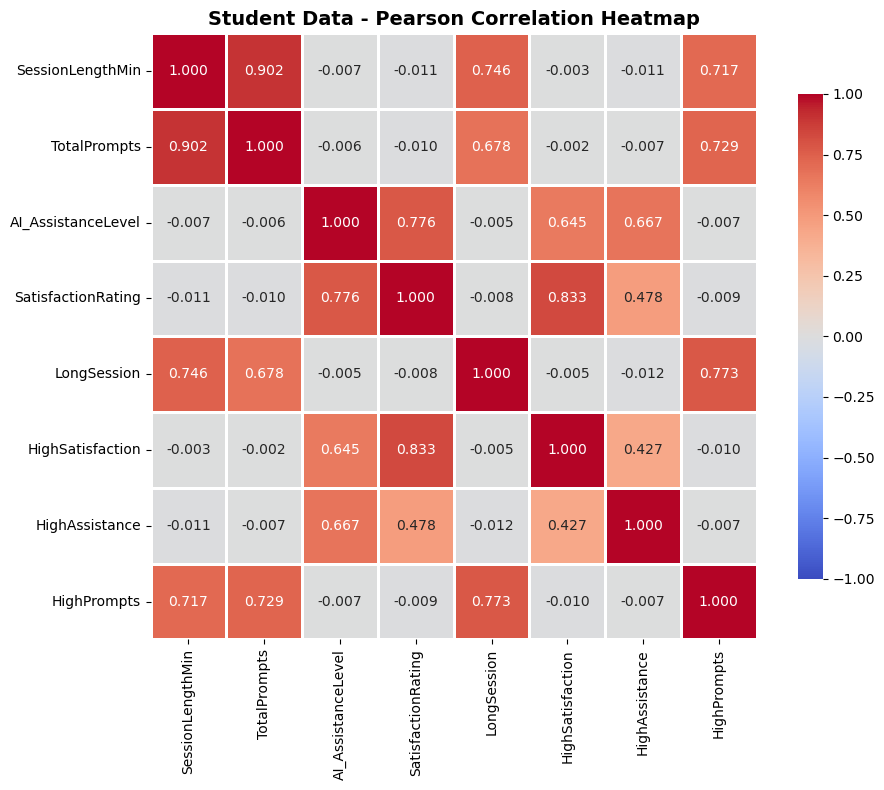

In [46]:
numeric_student = df_student.select_dtypes(include=[np.number])
corr_matrix_student = numeric_student.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_student, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', vmin=-1, vmax=1)
plt.title('Student Data - Pearson Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


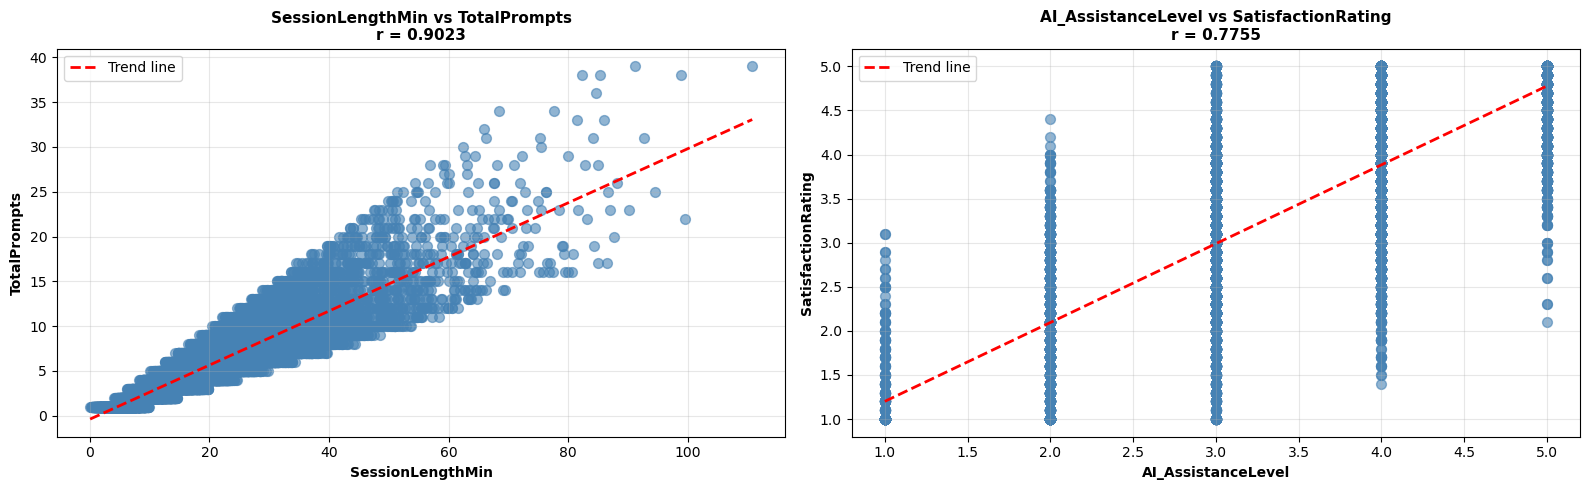

In [47]:
sig_student = student_pearson[student_pearson['p_value'] < 0.05]

if len(sig_student) > 0:
    fig, axes = plt.subplots(1, len(sig_student), figsize=(16, 5))
    if len(sig_student) == 1:
        axes = [axes]
    
    for ax, row in zip(axes, sig_student.iterrows()):
        row_data = row[1]
        var1, var2 = row_data['variable_1'], row_data['variable_2']
        corr_val = row_data['correlation']
        
        ax.scatter(df_student[var1], df_student[var2], alpha=0.6, s=50, color='steelblue')
        z = np.polyfit(df_student[var1], df_student[var2], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(df_student[var1].min(), df_student[var1].max(), 100)
        ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend line')
        ax.set_xlabel(var1, fontsize=10, fontweight='bold')
        ax.set_ylabel(var2, fontsize=10, fontweight='bold')
        ax.set_title(f'{var1} vs {var2}\nr = {corr_val}', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.show()


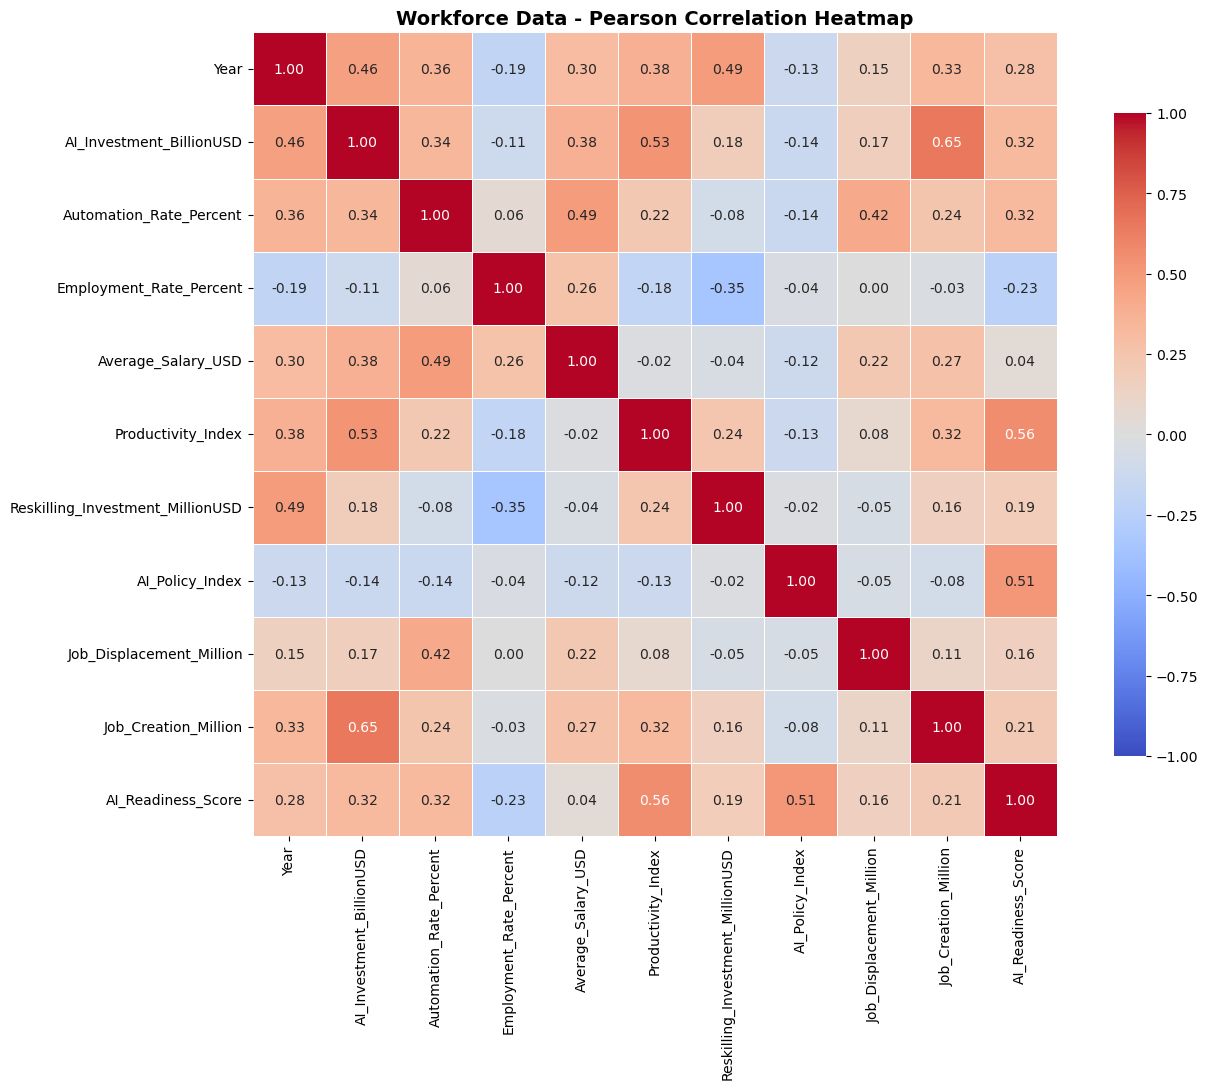

In [48]:
numeric_workforce = df_workforce.select_dtypes(include=[np.number])
corr_matrix_workforce = numeric_workforce.corr(method='pearson')

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix_workforce, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            fmt='.2f', vmin=-1, vmax=1)
plt.title('Workforce Data - Pearson Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


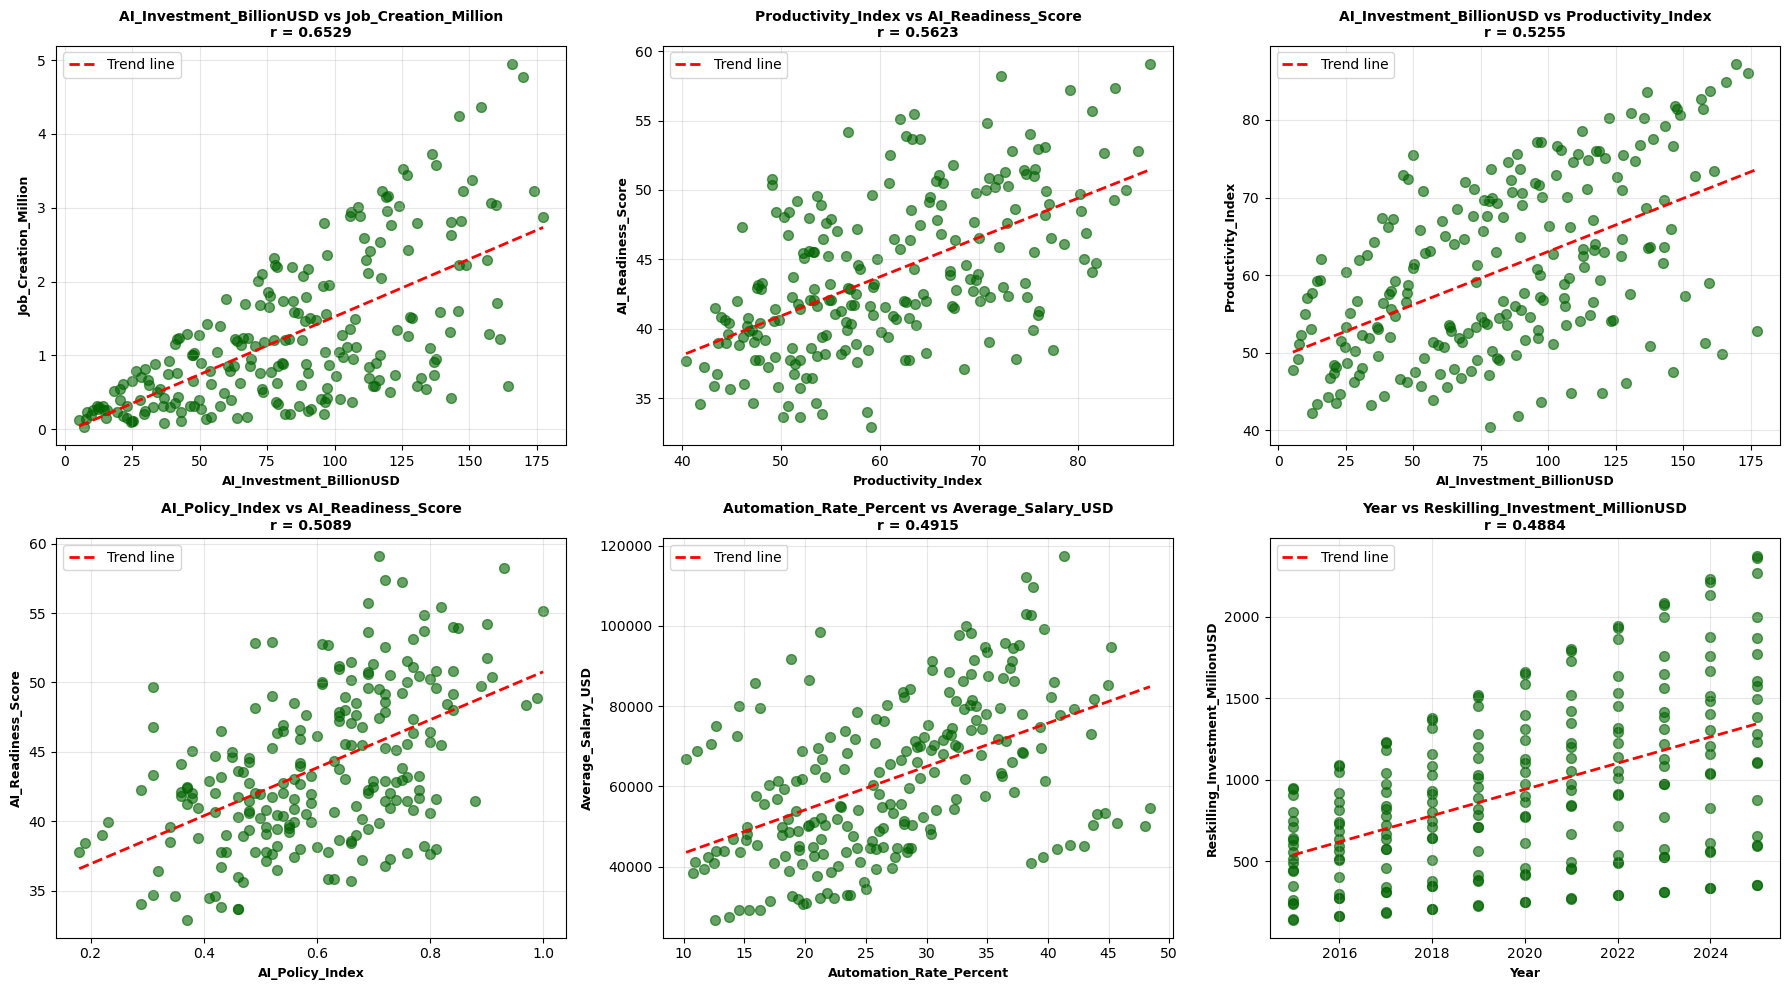

In [49]:
sig_workforce = workforce_pearson[workforce_pearson['p_value'] < 0.05]
sig_workforce_top = sig_workforce.sort_values('correlation', key=abs, ascending=False).head(6)

if len(sig_workforce_top) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for ax, row in zip(axes, sig_workforce_top.iterrows()):
        row_data = row[1]
        var1, var2 = row_data['variable_1'], row_data['variable_2']
        corr_val = row_data['correlation']
        
        ax.scatter(df_workforce[var1], df_workforce[var2], alpha=0.6, s=50, color='darkgreen')
        z = np.polyfit(df_workforce[var1], df_workforce[var2], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(df_workforce[var1].min(), df_workforce[var1].max(), 100)
        ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend line')
        ax.set_xlabel(var1, fontsize=9, fontweight='bold')
        ax.set_ylabel(var2, fontsize=9, fontweight='bold')
        ax.set_title(f'{var1} vs {var2}\nr = {corr_val}', fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.show()


In [50]:

print("INTERPRETATION & REAL-WORLD APPLICATION")

print("""
STUDENT DATA INSIGHTS:
1. SessionLengthMin vs TotalPrompts (r = 0.9023) - VERY STRONG
2. AI_AssistanceLevel vs SatisfactionRating (r = 0.7755) - STRONG

WORKFORCE DATA INSIGHTS:
- AI Investment correlates strongly with Job Creation
- Automation creates jobs despite displacement concerns
- AI Readiness Score predicts higher Productivity
""")


INTERPRETATION & REAL-WORLD APPLICATION

STUDENT DATA INSIGHTS:
1. SessionLengthMin vs TotalPrompts (r = 0.9023) - VERY STRONG
2. AI_AssistanceLevel vs SatisfactionRating (r = 0.7755) - STRONG

WORKFORCE DATA INSIGHTS:
- AI Investment correlates strongly with Job Creation
- Automation creates jobs despite displacement concerns
- AI Readiness Score predicts higher Productivity

